# Дипломный проект


## <center> 1. Постановка задачи на проект и EDA

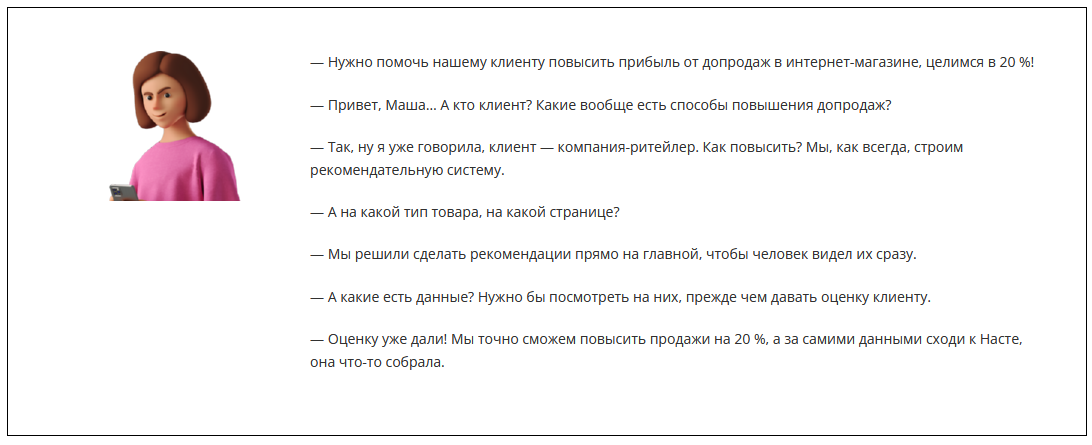

> Задачи от менеджера по проекту:
> 1. Необходимо повысить прибыль от продаж в интернет-магазине для нашего клиента (компания-ритейлер)
> 2. Построить рекомендательную систему. 
> 3. Сделать рекомендации на главной странице, чтобы покупатели видели их сразу.

## <center> 1.1 Описание данных:

**events — датасет с событиями. Колонки:**

    - timestamp — время события
    - visitorid — идентификатор пользователя
    - event — тип события
    - itemid — идентификатор объекта
    - transactionid — идентификатор транзакции, если она проходила

**category_tree — файл с деревом категорий (можно восстановить дерево).**

    - category_id — идентификатор категорий
    - parent_id — идентификатор родительской категории

**item_properties — файл с свойствами товаров.**

    - timestamp — момент записи значения свойства
    - item_id — идентификатор объекта
    - property — свойство, кажется, они все, кроме категории, захешированы
    - value — значение свойства


### <center> Импортируем библиотеки

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## <center> 1.2 Проверим и подгрузим **Events Log**

In [70]:
events_log = pd.read_csv('data_import/events.csv')
display(events_log.head(3))
display(events_log.info())
display(events_log.describe())
display(events_log.isna().sum())

print('Total Duplicates detected: {}'.format(events_log[events_log.duplicated()].shape[0]))
# Delete duplicates:
events_log = events_log.drop_duplicates()
print('Table size after delete duplicates: {}'.format(events_log.shape))

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


None

,timestamp,visitorid,itemid,transactionid
count,2.756101e+06,2.756101e+06,2.756101e+06,22457.000000
mean,1.436424e+12,7.019229e+05,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,3.507150e+05,13224.000000
max,1.442545e+12,1.407579e+06,4.668670e+05,17671.000000


timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

Total Duplicates detected: 460
Table size after delete duplicates: (2755641, 5)


### EDA по "events_log"

Размер датасета: 2,755,641 строк, 5 исходных признака
Период: 2015-05-03 — 2015-09-18
Уникальные пользователи: 1,407,580
Уникальные товары: 235,061
Пропуски transactionid: 99.2%

Распределение событий:


,count
event,
view,2664218
addtocart,68966
transaction,22457


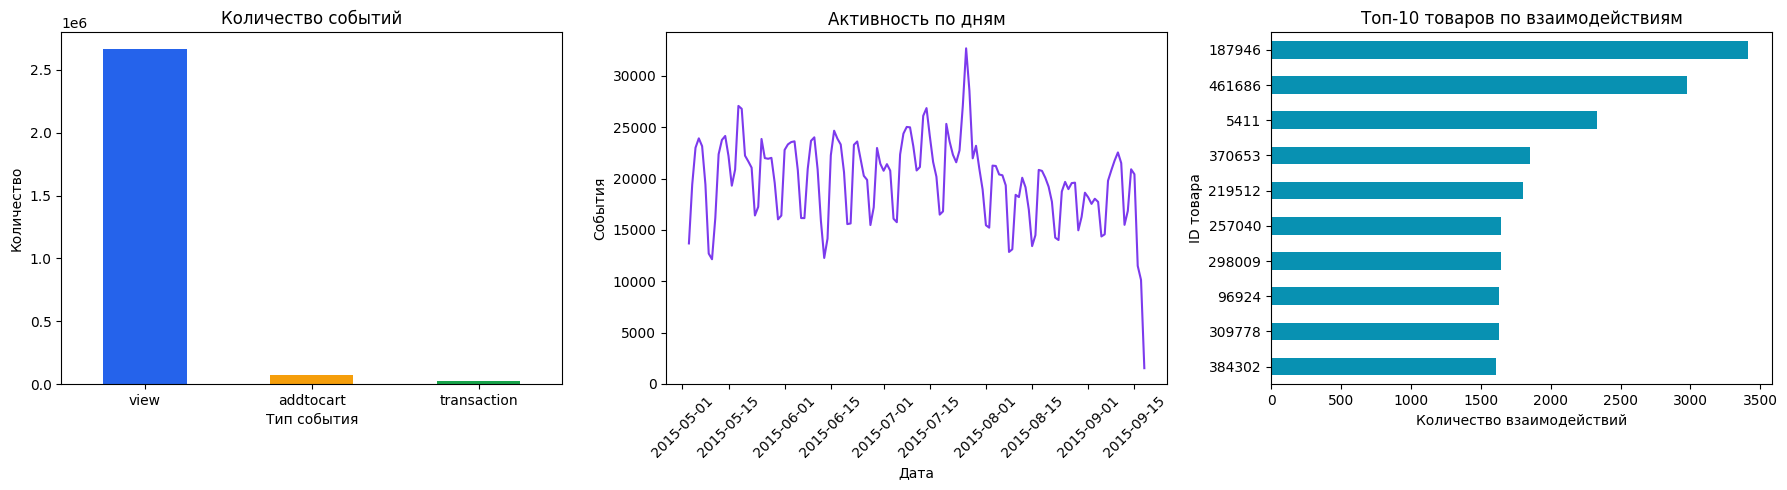

In [71]:

# Краткая сводка по событиям
eda_events = events_log.copy()
eda_events['event_datetime'] = pd.to_datetime(eda_events['timestamp'], unit='ms')
eda_events['date'] = eda_events['event_datetime'].dt.date

print(f'Размер датасета: {eda_events.shape[0]:,} строк, {eda_events.shape[1] - 2} исходных признака')
print(f'Период: {eda_events["event_datetime"].min():%Y-%m-%d} — {eda_events["event_datetime"].max():%Y-%m-%d}')
print(f'Уникальные пользователи: {eda_events["visitorid"].nunique():,}')
print(f'Уникальные товары: {eda_events["itemid"].nunique():,}')
print(f'Пропуски transactionid: {eda_events["transactionid"].isna().mean():.1%}')
print('\nРаспределение событий:')
display(eda_events['event'].value_counts().to_frame('count'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Типы взаимодействий
eda_events['event'].value_counts().plot.bar(ax=axes[0], color=['#2563eb', '#f59e0b', '#16a34a'])
axes[0].set_title('Количество событий')
axes[0].set_xlabel('Тип события')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=0)

# Динамика активности по дням
eda_events.groupby('date').size().plot(ax=axes[1], color='#7c3aed')
axes[1].set_title('Активность по дням')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('События')
axes[1].tick_params(axis='x', rotation=45)

# Топ товаров по числу взаимодействий
eda_events['itemid'].value_counts().head(10).sort_values().plot.barh(ax=axes[2], color='#0891b2')
axes[2].set_title('Топ-10 товаров по взаимодействиям')
axes[2].set_xlabel('Количество взаимодействий')
axes[2].set_ylabel('ID товара')

plt.tight_layout()
plt.show()

### На графике активности заметны повторяющиеся недельные колебания и резкое падение в конце периода. Уточним временной ряд: активность по дням недели и полноту последнего дня; в графике сейчас конец периода может выглядеть как спад спроса, хотя это может быть неполная выгрузка.

Последняя дата в данных: 2015-09-18
Время последнего события: 2015-09-18 02:59:47
Событий за последнюю дату: 1,528
Оценка полноты последней даты: вероятно неполная

Активность по дням недели (последняя неполная дата исключена):


,Число полных дат,Среднее событий,Медиана событий,Станд. отклонение
weekday_num,,,,
Понедельник,20,21986.90,21765.0,3147.90
Вторник,20,22350.30,22183.5,2392.86
Среда,20,21552.95,22097.0,3071.33
Четверг,20,20933.60,21498.0,3114.31
Пятница,19,19899.79,19871.0,1913.39
Суббота,19,16061.42,15495.0,3390.04
Воскресенье,20,16718.75,15948.5,4377.42


Последний день (Пятница): 1,528 событий; среднее за полные пятница (19 дат): 19,900 событий.


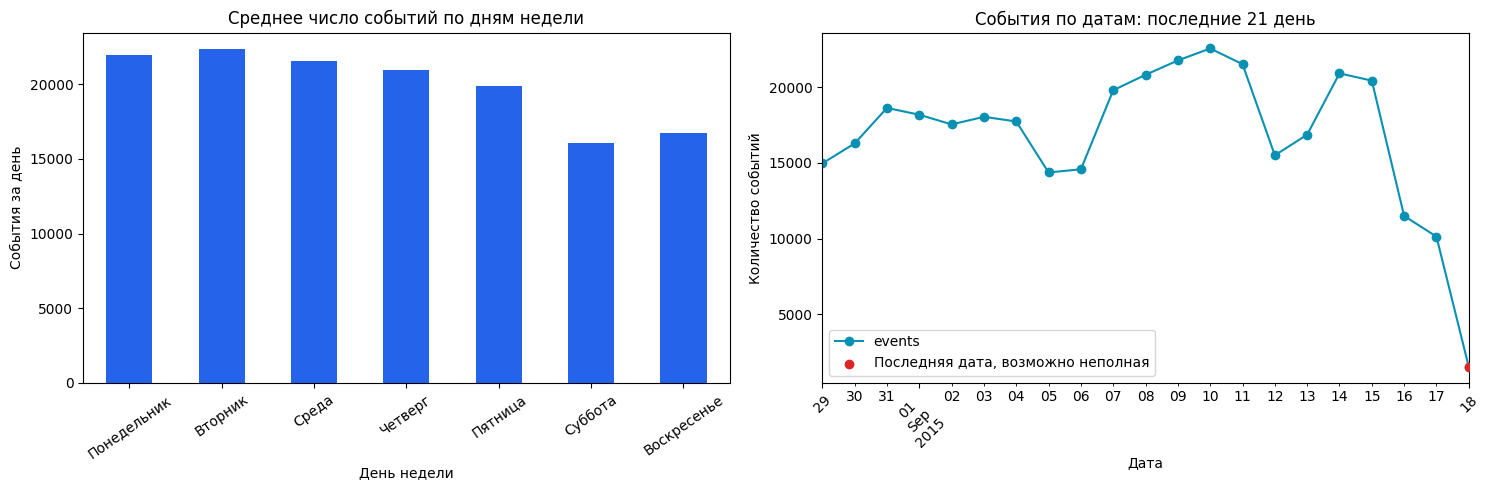

In [72]:
# Активность по дням недели и полнота последнего дня
activity = events_log[['timestamp']].copy()
activity['event_datetime'] = pd.to_datetime(activity['timestamp'], unit='ms')
activity['date'] = activity['event_datetime'].dt.normalize()
activity['weekday_num'] = activity['event_datetime'].dt.dayofweek

activity_by_date = activity.groupby('date').size().rename('events').to_frame()
latest_date = activity['date'].max()
latest_event_time = activity['event_datetime'].max()
latest_event_hour = latest_event_time.hour

# Считаем крайний день неполным, если в данных нет событий после 23:00.
latest_day_is_partial = latest_event_hour < 23
complete_days = activity_by_date.index < latest_date if latest_day_is_partial else activity_by_date.index <= latest_date
complete_daily_activity = activity_by_date.loc[complete_days].copy()
complete_daily_activity['weekday_num'] = complete_daily_activity.index.dayofweek

weekday_names_ru = {
    0: 'Понедельник',
    1: 'Вторник',
    2: 'Среда',
    3: 'Четверг',
    4: 'Пятница',
    5: 'Суббота',
    6: 'Воскресенье',
}
weekday_summary = (
    complete_daily_activity.groupby('weekday_num')['events']
    .agg(['count', 'mean', 'median', 'std'])
    .rename(columns={
        'count': 'Число полных дат',
        'mean': 'Среднее событий',
        'median': 'Медиана событий',
        'std': 'Станд. отклонение',
    })
)
weekday_summary.index = weekday_summary.index.map(weekday_names_ru)

print(f'Последняя дата в данных: {latest_date:%Y-%m-%d}')
print(f'Время последнего события: {latest_event_time:%Y-%m-%d %H:%M:%S}')
print(f'Событий за последнюю дату: {activity_by_date.loc[latest_date, "events"]:,}')
print(
    'Оценка полноты последней даты: '
    + ('вероятно неполная' if latest_day_is_partial else 'похожа на полную по времени последнего события')
)
print('\nАктивность по дням недели (последняя неполная дата исключена):')
display(weekday_summary.round(2))

if latest_day_is_partial:
    same_weekday = latest_date.dayofweek
    previous_same_weekday = complete_daily_activity[
        complete_daily_activity['weekday_num'].eq(same_weekday)
    ]['events']
    reference_mean = previous_same_weekday.mean()
    partial_count = activity_by_date.loc[latest_date, 'events']
    print(
        f'Последний день ({weekday_names_ru[same_weekday]}): {partial_count:,} событий; '
        f'среднее за полные {weekday_names_ru[same_weekday].lower()} '
        f'({len(previous_same_weekday)} дат): {reference_mean:,.0f} событий.'
    )

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
weekday_summary['Среднее событий'].plot.bar(ax=axes[0], color='#2563eb')
axes[0].set_title('Среднее число событий по дням недели')
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('События за день')
axes[0].tick_params(axis='x', rotation=35)

activity_by_date['events'].tail(21).plot(ax=axes[1], marker='o', color='#0891b2')
if latest_day_is_partial:
    axes[1].scatter(
        latest_date,
        activity_by_date.loc[latest_date, 'events'],
        color='#dc2626',
        label='Последняя дата, возможно неполная',
        zorder=3,
    )
    axes[1].legend()
axes[1].set_title('События по датам: последние 21 день')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Количество событий')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Исключённая дата: 2015-09-18
Удалено строк: 1,528
Строк после исключения даты: 2,754,113


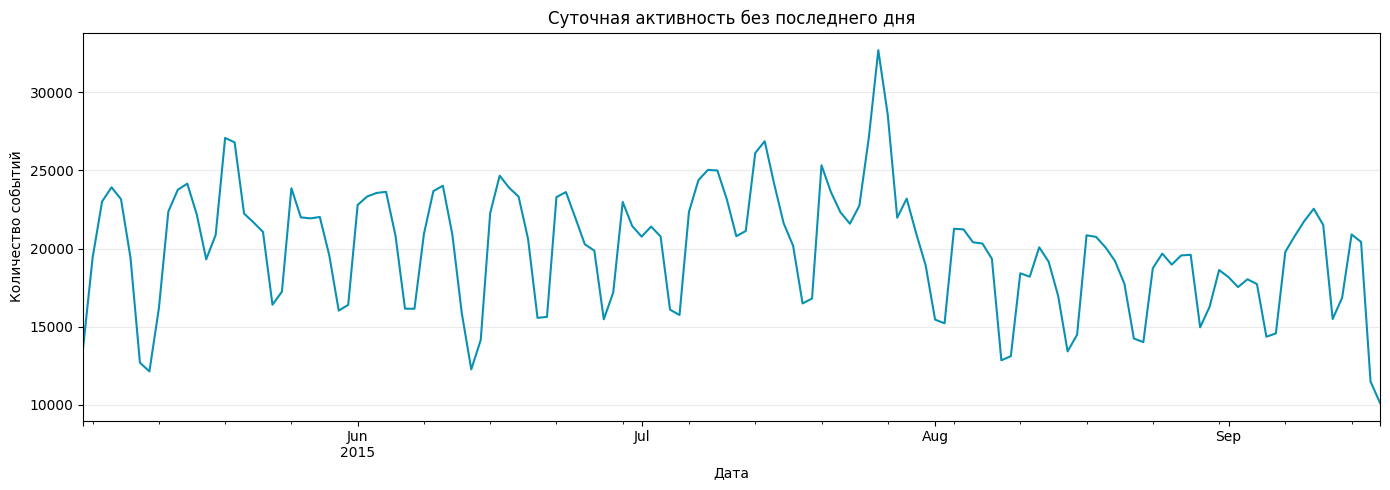

In [73]:
# Исключаем последнюю календарную дату, не изменяя исходный events_log
last_event_date = pd.to_datetime(events_log['timestamp'], unit='ms').dt.normalize().max()
event_datetimes = pd.to_datetime(events_log['timestamp'], unit='ms')
events_log_without_last_day = events_log.loc[
    event_datetimes.dt.normalize() < last_event_date
].copy()

removed_rows = len(events_log) - len(events_log_without_last_day)
print(f'Исключённая дата: {last_event_date:%Y-%m-%d}')
print(f'Удалено строк: {removed_rows:,}')
print(f'Строк после исключения даты: {len(events_log_without_last_day):,}')

activity_without_last_day = events_log_without_last_day.copy()
activity_without_last_day['event_datetime'] = pd.to_datetime(
    activity_without_last_day['timestamp'], unit='ms'
)
daily_activity_without_last_day = (
    activity_without_last_day
    .set_index('event_datetime')
    .resample('D')
    .size()
)

ax = daily_activity_without_last_day.plot(
    figsize=(14, 5),
    color='#0891b2',
    linewidth=1.5,
)
ax.set_title('Суточная активность без последнего дня')
ax.set_xlabel('Дата')
ax.set_ylabel('Количество событий')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

### Проверим статистику по транзакциям и покупателям:
1. просмотр → корзина → покупка
2. отдельно покажем долю посетителей, дошедших до каждого этапа.

In [74]:
# Воронка просмотров, добавлений в корзину и покупок
funnel_events = events_log[['visitorid', 'event', 'timestamp']].copy()
funnel_events['event_datetime'] = pd.to_datetime(funnel_events['timestamp'], unit='ms')


def ordered_funnel(data, entity_col):
    first_views = (
        data[data['event'].eq('view')]
        .groupby(entity_col)['timestamp']
        .min()
    )

    cart_events = data[data['event'].eq('addtocart')][[entity_col, 'timestamp']].copy()
    cart_events = cart_events[
        cart_events['timestamp'].gt(cart_events[entity_col].map(first_views))
    ]
    first_carts = cart_events.groupby(entity_col)['timestamp'].min()

    purchase_events = data[data['event'].eq('transaction')][[entity_col, 'timestamp']].copy()
    purchase_events = purchase_events[
        purchase_events['timestamp'].gt(purchase_events[entity_col].map(first_carts))
    ]
    first_purchases = purchase_events.groupby(entity_col)['timestamp'].min()

    stage_counts = [len(first_views), len(first_carts), len(first_purchases)]
    funnel = pd.DataFrame(
        {
            'Этап': ['Просмотр', 'Добавление в корзину', 'Покупка'],
            'Количество': stage_counts,
            'Доля от начального этапа, %': [
                count / stage_counts[0] * 100 if stage_counts[0] else 0
                for count in stage_counts
            ],
            'Конверсия с предыдущего этапа, %': [
                100,
                stage_counts[1] / stage_counts[0] * 100 if stage_counts[0] else 0,
                stage_counts[2] / stage_counts[1] * 100 if stage_counts[1] else 0,
            ],
        }
    )
    return funnel


print('Пользовательская воронка:')
display(ordered_funnel(funnel_events, 'visitorid').round(2))

# Сессия определяется разрывом активности пользователя более чем на 30 минут.
funnel_events = funnel_events.sort_values(['visitorid', 'timestamp'])
new_session = (
    funnel_events.groupby('visitorid')['event_datetime']
    .diff()
    .gt(pd.Timedelta(minutes=30))
    .fillna(True)
)
funnel_events['session_id'] = new_session.cumsum()

print('Сессионная воронка (эвристика: разрыв более 30 минут):')
display(ordered_funnel(funnel_events, 'session_id').round(2))

Пользовательская воронка:


,Этап,Количество,"Доля от начального этапа, %","Конверсия с предыдущего этапа, %"
0,Просмотр,1404179,100.00,100.00
1,Добавление в корзину,32934,2.35,2.35
2,Покупка,9952,0.71,30.22


Сессионная воронка (эвристика: разрыв более 30 минут):


,Этап,Количество,"Доля от начального этапа, %","Конверсия с предыдущего этапа, %"
0,Просмотр,353186,100.00,100.00
1,Добавление в корзину,38143,10.80,10.80
2,Покупка,11347,3.21,29.75


### Проверим частоту взаимодействий на пользователя и товар, повторные покупки, долю пользователей и товаров только с одним событием:

In [75]:
# Частота взаимодействий на пользователя и товар
interactions_per_user = events_log.groupby('visitorid').size()
interactions_per_item = events_log.groupby('itemid').size()

frequency_summary = pd.DataFrame(
    {
        'Пользователь': interactions_per_user.describe(
            percentiles=[0.25, 0.5, 0.75, 0.9]
        ),
        'Товар': interactions_per_item.describe(
            percentiles=[0.25, 0.5, 0.75, 0.9]
        ),
    }
).T
frequency_summary['Объектов с одним событием'] = [
    interactions_per_user.eq(1).sum(),
    interactions_per_item.eq(1).sum(),
]
frequency_summary['Доля с одним событием, %'] = [
    interactions_per_user.eq(1).mean() * 100,
    interactions_per_item.eq(1).mean() * 100,
]

print('Событий на пользователя и товар:')
display(frequency_summary.round(2))

# Повторная покупка: более одного уникального заказа на пользователя
purchase_rows = events_log.loc[
    events_log['event'].eq('transaction') & events_log['transactionid'].notna(),
    ['visitorid', 'itemid', 'transactionid'],
]
orders_per_buyer = purchase_rows.groupby('visitorid')['transactionid'].nunique()
repeat_buyers = orders_per_buyer[orders_per_buyer > 1]

print(f'Покупателей с транзакциями: {len(orders_per_buyer):,}')
print(f'Пользователей с повторными покупками: {len(repeat_buyers):,}')
print(
    'Доля повторных покупателей среди покупателей: '
    f'{len(repeat_buyers) / len(orders_per_buyer) * 100:.2f}%'
)
print(f'Максимум транзакций на пользователя: {orders_per_buyer.max():,}')

# Повторная покупка одного и того же товара в разных заказах
orders_per_user_item = purchase_rows.groupby(
    ['visitorid', 'itemid']
)['transactionid'].nunique()
repeat_item_pairs = orders_per_user_item[orders_per_user_item > 1]
print(f'Пар пользователь-товар с покупкой в разных транзакциях: {len(repeat_item_pairs):,}')
print(f'Пользователей, повторно купивших тот же товар: {repeat_item_pairs.index.get_level_values("visitorid").nunique():,}')

Событий на пользователя и товар:


,count,mean,std,min,25%,50%,75%,90%,max,Объектов с одним событием,"Доля с одним событием, %"
Пользователь,1407580.0,1.96,12.58,1.0,1.0,1.0,2.0,3.0,7757.0,1001591,71.16
Товар,235061.0,11.72,37.02,1.0,1.0,3.0,9.0,25.0,3412.0,73616,31.32


Покупателей с транзакциями: 11,719
Пользователей с повторными покупками: 1,063
Доля повторных покупателей среди покупателей: 9.07%
Максимум транзакций на пользователя: 502
Пар пользователь-товар с покупкой в разных транзакциях: 891
Пользователей, повторно купивших тот же товар: 588


## <center> 1.3 Проверим и подгрузим **Category Tree**

In [76]:
category_tree = pd.read_csv('data_import/category_tree.csv')
display(category_tree.head(3))
display(category_tree.info())
display(category_tree.describe())
display(category_tree.isna().sum())

print('Total Duplicates detected: {}'.format(category_tree[category_tree.duplicated()].shape[0]))
# Delete duplicates:
category_tree = category_tree.drop_duplicates()
print('Table size after delete duplicates: {}'.format(category_tree.shape))

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB


None

,categoryid,parentid
count,1669.000000,1644.000000
mean,849.285201,847.571168
std,490.195116,505.058485
min,0.000000,8.000000
25%,427.000000,381.000000
50%,848.000000,866.000000
75%,1273.000000,1291.000000
max,1698.000000,1698.000000


categoryid     0
parentid      25
dtype: int64

Total Duplicates detected: 0
Table size after delete duplicates: (1669, 2)


### EDA по "category_tree"

Размер дерева: 1,669 категорий
Уникальные категории: 1,669
Пропуски в родительской категории: 25
Корневые категории: 25
Максимальное число дочерних категорий: 31

Первые строки:


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


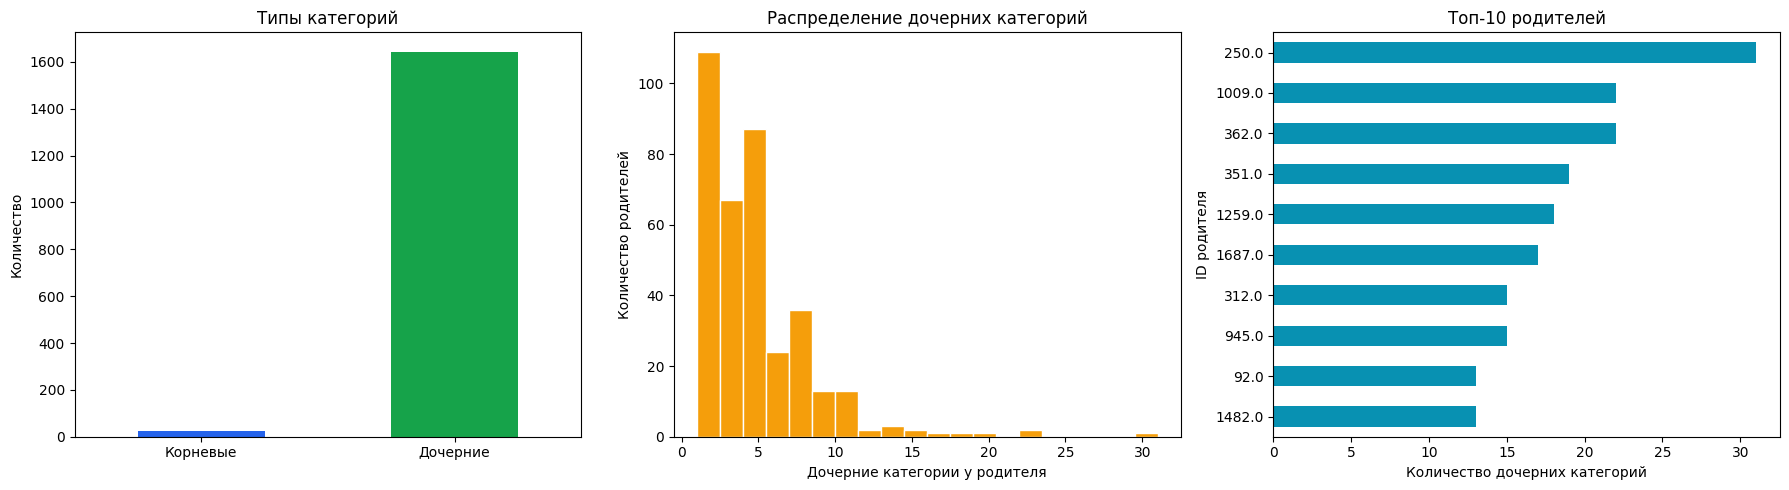

In [77]:
# Краткая сводка по дереву категорий
eda_categories = category_tree.copy()
category_col = next(col for col in ('categoryid', 'category_id') if col in eda_categories.columns)
parent_col = next(col for col in ('parentid', 'parent_id') if col in eda_categories.columns)

root_categories = eda_categories[parent_col].isna().sum()
children_by_parent = eda_categories[parent_col].dropna().value_counts()

print(f'Размер дерева: {eda_categories.shape[0]:,} категорий')
print(f'Уникальные категории: {eda_categories[category_col].nunique():,}')
print(f'Пропуски в родительской категории: {eda_categories[parent_col].isna().sum():,}')
print(f'Корневые категории: {root_categories:,}')
print(f'Максимальное число дочерних категорий: {children_by_parent.max():,}')
print('\nПервые строки:')
display(eda_categories.head())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Корневые и дочерние категории
pd.Series(
    {'Корневые': root_categories, 'Дочерние': len(eda_categories) - root_categories}
).plot.bar(ax=axes[0], color=['#2563eb', '#16a34a'])
axes[0].set_title('Типы категорий')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=0)

# Распределение количества дочерних категорий у родителей
children_by_parent.plot.hist(ax=axes[1], bins=20, color='#f59e0b', edgecolor='white')
axes[1].set_title('Распределение дочерних категорий')
axes[1].set_xlabel('Дочерние категории у родителя')
axes[1].set_ylabel('Количество родителей')

# Топ родителей по числу дочерних категорий
top_parents = children_by_parent.head(10).sort_values()
top_parents.index = top_parents.index.astype(str)
top_parents.plot.barh(ax=axes[2], color='#0891b2')
axes[2].set_title('Топ-10 родителей')
axes[2].set_xlabel('Количество дочерних категорий')
axes[2].set_ylabel('ID родителя')

plt.tight_layout()
plt.show()

## <center> 1.4 Проверим и подгрузим **item_properties_part1 & item_properties_part2**

### Проверим и подгрузим **item_properties_part1**

In [78]:
item_properties_part1 = pd.read_csv('data_import/item_properties_part1.csv')
display(item_properties_part1.head(3))
display(item_properties_part1.info())
display(item_properties_part1.describe())
display(item_properties_part1.isna().sum())

print('Total Duplicates detected: {}'.format(item_properties_part1[item_properties_part1.duplicated()].shape[0]))
# Delete duplicates:
item_properties_part1 = item_properties_part1.drop_duplicates()
print('Table size after delete duplicates: {}'.format(item_properties_part1.shape))

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999999 entries, 0 to 10999998
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 335.7+ MB


None

,timestamp,itemid
count,1.100000e+07,1.100000e+07
mean,1.435158e+12,2.333851e+05
std,3.327653e+09,1.348258e+05
min,1.431227e+12,0.000000e+00
25%,1.432436e+12,1.165150e+05
50%,1.433646e+12,2.334990e+05
75%,1.437880e+12,3.501860e+05
max,1.442113e+12,4.668660e+05


timestamp    0
itemid       0
property     0
value        0
dtype: int64

Total Duplicates detected: 0
Table size after delete duplicates: (10999999, 4)


### Проверим и подгрузим **item_properties_part2**

In [79]:
item_properties_part2 = pd.read_csv('data_import/item_properties_part2.csv')
display(item_properties_part2.head(3))
display(item_properties_part2.info())
display(item_properties_part2.describe())
display(item_properties_part2.isna().sum())

print('Total Duplicates detected: {}'.format(item_properties_part2[item_properties_part2.duplicated()].shape[0]))
# Delete duplicates:
item_properties_part2 = item_properties_part2.drop_duplicates()
print('Table size after delete duplicates: {}'.format(item_properties_part2.shape))

,timestamp,itemid,property,value
0,1433041200000,183478,561,769062
1,1439694000000,132256,976,n26.400 1135780
2,1435460400000,420307,921,1149317 1257525


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9275903 entries, 0 to 9275902
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 283.1+ MB


None

,timestamp,itemid
count,9.275903e+06,9.275903e+06
mean,1.435156e+12,2.333968e+05
std,3.327970e+09,1.348682e+05
min,1.431227e+12,0.000000e+00
25%,1.432436e+12,1.165175e+05
50%,1.433646e+12,2.334620e+05
75%,1.437880e+12,3.504470e+05
max,1.442113e+12,4.668660e+05


timestamp    0
itemid       0
property     0
value        0
dtype: int64

Total Duplicates detected: 0
Table size after delete duplicates: (9275903, 4)


### EDA по "item_properties_part1 & item_properties_part2"

Общий размер: 20,275,902 строк
Уникальные товары: 417,053
Уникальные свойства: 1,104
Уникальные значения свойств: 1,966,868
Дубликаты: 0

Пропуски:


,count
timestamp,0
itemid,0
property,0
value,0


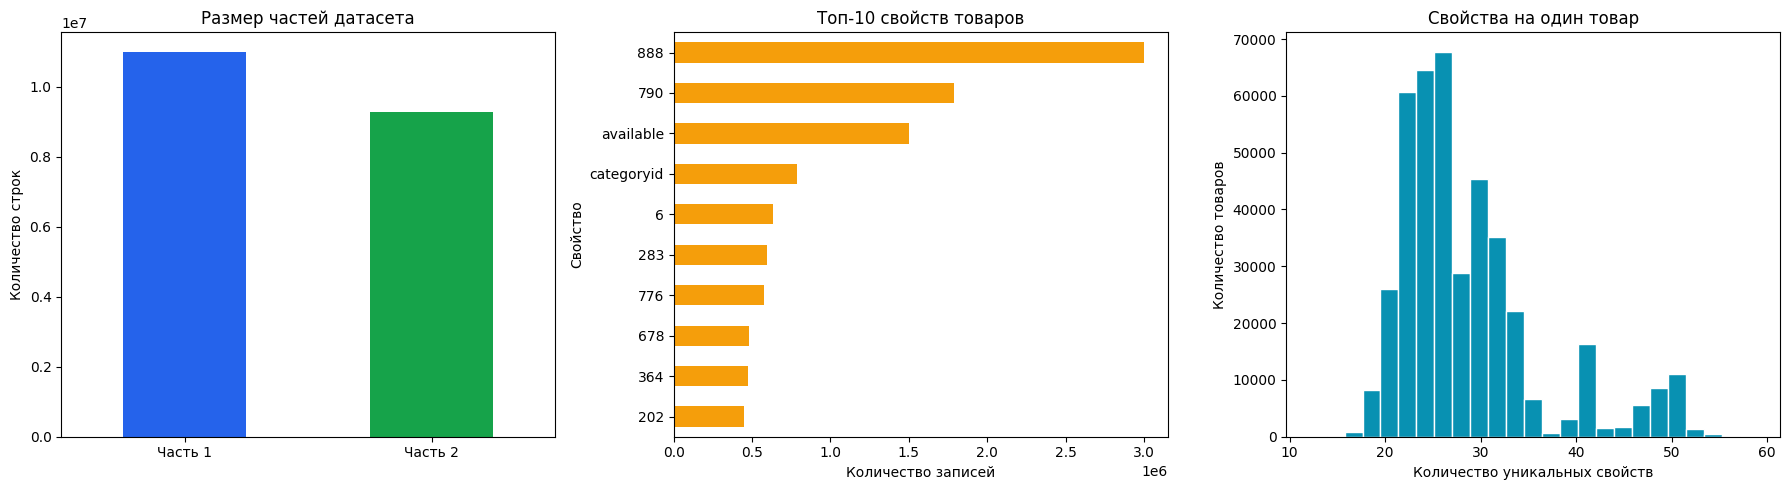

In [80]:
# Краткая сводка по свойствам товаров
properties_part1 = item_properties_part1.copy()
properties_part2 = item_properties_part2.copy()
item_properties = pd.concat(
    [properties_part1, properties_part2],
    ignore_index=True
)
item_col = next(col for col in ('itemid', 'item_id') if col in item_properties.columns)

print(f'Общий размер: {item_properties.shape[0]:,} строк')
print(f'Уникальные товары: {item_properties[item_col].nunique():,}')
print(f'Уникальные свойства: {item_properties["property"].nunique():,}')
print(f'Уникальные значения свойств: {item_properties["value"].nunique():,}')
print(f'Дубликаты: {item_properties.duplicated().sum():,}')
print('\nПропуски:')
display(item_properties.isna().sum().to_frame('count'))

properties_per_item = item_properties.groupby(item_col)['property'].nunique()
top_properties = item_properties['property'].value_counts().head(10).sort_values()
part_sizes = pd.Series({
    'Часть 1': len(properties_part1),
    'Часть 2': len(properties_part2)
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Объём частей датасета
part_sizes.plot.bar(ax=axes[0], color=['#2563eb', '#16a34a'])
axes[0].set_title('Размер частей датасета')
axes[0].set_ylabel('Количество строк')
axes[0].tick_params(axis='x', rotation=0)

# Самые часто встречающиеся свойства
top_properties.plot.barh(ax=axes[1], color='#f59e0b')
axes[1].set_title('Топ-10 свойств товаров')
axes[1].set_xlabel('Количество записей')
axes[1].set_ylabel('Свойство')

# Покрытие товаров свойствами
properties_per_item.plot.hist(ax=axes[2], bins=25, color='#0891b2', edgecolor='white')
axes[2].set_title('Свойства на один товар')
axes[2].set_xlabel('Количество уникальных свойств')
axes[2].set_ylabel('Количество товаров')

plt.tight_layout()
plt.show()

### Оценим покрытие товаров событиями и проверим связи свойств и категорий

In [81]:
event_item_id_col = 'itemid'
property_item_id_col = next(
    col for col in ('itemid', 'item_id') if col in item_properties.columns
)
category_tree_id_col = next(
    col for col in ('categoryid', 'category_id') if col in category_tree.columns
)

# Приводим идентификаторы к числовому виду для корректного сравнения
item_ids_in_events = set(
    pd.to_numeric(events_log[event_item_id_col], errors='coerce').dropna().astype('int64')
)
item_ids_in_properties = set(
    pd.to_numeric(item_properties[property_item_id_col], errors='coerce').dropna().astype('int64')
)
category_ids_in_tree = set(
    pd.to_numeric(category_tree[category_tree_id_col], errors='coerce').dropna().astype('int64')
)

property_items_in_events = item_ids_in_events & item_ids_in_properties
category_property_mask = (
    item_properties['property']
    .astype(str)
    .str.lower()
    .str.replace('_', '', regex=False)
    .eq('categoryid')
)
category_property_rows = item_properties.loc[
    category_property_mask, [property_item_id_col, 'value']
].copy()
category_property_rows['category_id_numeric'] = pd.to_numeric(
    category_property_rows['value'], errors='coerce'
)
category_property_rows = category_property_rows.dropna(subset=['category_id_numeric'])
category_property_rows[property_item_id_col] = pd.to_numeric(
    category_property_rows[property_item_id_col], errors='coerce'
)
category_property_rows = category_property_rows.dropna(subset=[property_item_id_col])
category_property_rows[property_item_id_col] = category_property_rows[
    property_item_id_col
].astype('int64')

items_with_category_in_events = (
    item_ids_in_events
    & set(category_property_rows[property_item_id_col].unique())
)
valid_category_rows = category_property_rows[
    category_property_rows['category_id_numeric'].isin(category_ids_in_tree)
]
items_with_valid_category_in_events = (
    item_ids_in_events
    & set(valid_category_rows[property_item_id_col].unique())
)

coverage_counts = pd.DataFrame(
    {
        'Товаров': [
            len(item_ids_in_events),
            len(property_items_in_events),
            len(items_with_category_in_events),
            len(items_with_valid_category_in_events),
        ],
    },
    index=[
        'Уникальные товары в событиях',
        'Есть хотя бы одно свойство',
        'Есть свойство categoryid',
        'Категория найдена в дереве',
    ],
)
coverage_counts['Покрытие товаров из событий, %'] = (
    coverage_counts['Товаров'] / len(item_ids_in_events) * 100
)

print(
    f'Проверка связи {event_item_id_col} с {property_item_id_col}: '
    f'{len(property_items_in_events):,} из {len(item_ids_in_events):,} товаров событий '
    'найдены в свойствах.'
)
print(f'Товаров событий без записи в свойствах: {len(item_ids_in_events - item_ids_in_properties):,}')
print(
    f'Категорий в дереве: {len(category_ids_in_tree):,}; '
    f'категорийных записей без соответствия дереву: '
    f'{category_property_rows[~category_property_rows["category_id_numeric"].isin(category_ids_in_tree)].shape[0]:,}'
)
display(coverage_counts.round(2))

Проверка связи itemid с itemid: 185,246 из 235,061 товаров событий найдены в свойствах.
Товаров событий без записи в свойствах: 49,815
Категорий в дереве: 1,669; категорийных записей без соответствия дереву: 167


,Товаров,"Покрытие товаров из событий, %"
Уникальные товары в событиях,235061,100.00
Есть хотя бы одно свойство,185246,78.81
Есть свойство categoryid,185246,78.81
Категория найдена в дереве,185246,78.81


### <center> Задание 2.3

Сколько уникальных признаков товара есть в датасете? Ответ вводите без пробелов и знаков препинания.

In [82]:
item_properties = pd.concat(
    [item_properties_part1, item_properties_part2],
    ignore_index=True
)

unique_properties = item_properties['property'].nunique()
print(unique_properties)

1104


### <center> Задание 2.4

Анастасия: Кстати, слушай… Это, конечно, не моё дело, но мы же не можем оптимизировать оборот? Как думаешь, как мы будем измерять качество рекомендаций? У нас вроде только три места для показа товаров на главной странице. А ведь клиента интересует только продажи!
 
> Ответ: Precision@3


# <center> 3. Декомпозиция на четыре этапа и задача текущего спринта

### Ожидаемые результаты:

1. Создан сервис, выдающий рекомендации по идентификатору пользователя.
2. Сервис обёрнут в Docker.
3. У сервиса есть понятная документация, описание функциональности.
4. Сделана презентация для менеджера с описанием принципов работы.


### Разбиение по подзадачам:

| Таск | Подзадача | Неделя |
|---|---|---|
| 1 Постановка задачи | Уточнение бизнес-постановки задачи | 1 |
|  | Выбор технических метрик качества | 1 |
|  | Получение данных | 1 |
| 2 Исследование данных | Описание структуры данных | 1 |
|  |  Статистический анализ данных | 1 |
| 3 Создание факторов для модели | Генерация факторов, связанных с айтемами | 2 |
|  | Генерация факторов айтем-юзер | 2 |
| 4 Проведение экспериментов | Коллаборативная фильтрация | 3 |
|  | Факторизационные машины | 3 |
|  | XGBoost для задачи классификации | 3 |
| 5 Создание MVP | Проектирование API сервиса | 4 |
|  | Создание веб-сервиса с моделью | 4 |
| 6 Контейнеризация | Создание Docker-контейнера с сервисом | 4 |

# <center> 4. Дополнительная задача от продакт-менеджера

### Задание 4.1

Какой процент продаж обеспечивают топовые товары (точка отсечения — 1 июля)? Для расчёта используйте топ-3 товаров по числу транзакций.


In [83]:
events_with_datetime = events_log.copy()
events_with_datetime['event_datetime'] = pd.to_datetime(
    events_with_datetime['timestamp'],
    unit='ms'
)

# Проверяем соответствие типа события и наличия transactionid
has_transaction_id = events_with_datetime['transactionid'].notna()
is_transaction_event = events_with_datetime['event'].eq('transaction')
non_transaction_with_id = (has_transaction_id & ~is_transaction_event).sum()
transaction_without_id = (~has_transaction_id & is_transaction_event).sum()
print(f'Строк с transactionid, но event != transaction: {non_transaction_with_id:,}')
print(f'Событий transaction без transactionid: {transaction_without_id:,}')

# Берём события transaction до 1 июля включительно
cutoff_date = pd.Timestamp('2015-07-02')
sales_until_july = events_with_datetime[
    (events_with_datetime['event_datetime'] < cutoff_date)
    & is_transaction_event
    & has_transaction_id
]

transactions_by_item = (
    sales_until_july.groupby('itemid')['transactionid']
    .nunique()
    .sort_values(ascending=False)
    .rename('transactions')
    .reset_index()
)
top_3_items = transactions_by_item.head(3)
top_3_item_ids = top_3_items['itemid'].tolist()

sales_top_3_count = sales_until_july[
    sales_until_july['itemid'].isin(top_3_item_ids)
]['transactionid'].nunique()
total_sales_count = sales_until_july['transactionid'].nunique()
share_of_top_3 = sales_top_3_count / total_sales_count * 100

print('Период расчёта: до 1 июля 2015 включительно')
print(f'Топ-3 товаров: {top_3_item_ids}')
print(f'Транзакции топ-3: {sales_top_3_count:,}')
print(f'Все транзакции: {total_sales_count:,}')
print(f'Доля транзакций с товарами топ-3: {share_of_top_3:.2f}%')

Строк с transactionid, но event != transaction: 0
Событий transaction без transactionid: 0
Период расчёта: до 1 июля 2015 включительно
Топ-3 товаров: [119736, 369447, 7943]
Транзакции топ-3: 97
Все транзакции: 7,893
Доля транзакций с товарами топ-3: 1.23%


# <center> Дипломный проект - Неделя 2

## <center> 5. Генерация факторов и валидация с разбиением времени

### Задача:
1. Подготовим ноутбук с описанием данных и сгенерируем факторы
2. Постоим валидацию с разбиением по времени


## <center> 5.1 Генерация факторов, связанных с айтемами

In [84]:
# Оставляем последние 20% календарных дат для временной валидации.
item_events = events_log[['timestamp', 'visitorid', 'event', 'itemid']].copy()
item_events['datetime'] = pd.to_datetime(item_events['timestamp'], unit='ms')
item_events['date'] = item_events['datetime'].dt.normalize()
all_dates = np.sort(item_events['date'].unique())
validation_start = pd.Timestamp(all_dates[int(len(all_dates) * 0.8)])
train_events = item_events[item_events['datetime'] < validation_start].copy()
validation_events = item_events[item_events['datetime'] >= validation_start].copy()

# Поведенческие признаки товара рассчитываются только по обучающему периоду.
item_features = train_events.groupby('itemid').agg(
    n_interactions=('event', 'size'),
    n_unique_visitors=('visitorid', 'nunique'),
)
event_counts = pd.crosstab(train_events['itemid'], train_events['event'])
event_counts = event_counts.reindex(
    columns=['view', 'addtocart', 'transaction'], fill_value=0
).rename(columns={
    'view': 'n_views',
    'addtocart': 'n_addtocart_events',
    'transaction': 'n_transaction_events',
})
item_features = item_features.join(event_counts, how='left').fillna(0)

# Считаем уникальных пользователей, прошедших последовательные этапы по одному товару.
item_visitor_keys = ['itemid', 'visitorid']
view_times = (
    train_events[train_events['event'].eq('view')]
    .groupby(item_visitor_keys)['timestamp']
    .min()
    .rename('view_time')
    .reset_index()
)
cart_events = train_events[train_events['event'].eq('addtocart')][
    item_visitor_keys + ['timestamp']
].merge(view_times, on=item_visitor_keys)
cart_times = (
    cart_events[cart_events['timestamp'] > cart_events['view_time']]
    .groupby(item_visitor_keys)['timestamp']
    .min()
    .rename('cart_time')
    .reset_index()
)
purchase_events = train_events[train_events['event'].eq('transaction')][
    item_visitor_keys + ['timestamp']
].merge(cart_times, on=item_visitor_keys)
purchase_times = (
    purchase_events[purchase_events['timestamp'] > purchase_events['cart_time']]
    .groupby(item_visitor_keys)['timestamp']
    .min()
    .rename('purchase_time')
    .reset_index()
)
sequential_counts = pd.DataFrame(index=item_features.index)
sequential_counts['n_viewers'] = view_times.groupby('itemid')['visitorid'].nunique()
sequential_counts['n_cart_visitors_after_view'] = cart_times.groupby('itemid')['visitorid'].nunique()
sequential_counts['n_buyers_after_cart'] = purchase_times.groupby('itemid')['visitorid'].nunique()
item_features = item_features.join(sequential_counts).fillna(0)
item_features['view_to_cart_rate'] = (
    item_features['n_cart_visitors_after_view']
    / item_features['n_viewers'].replace(0, np.nan)
).fillna(0)
item_features['cart_to_purchase_rate'] = (
    item_features['n_buyers_after_cart']
    / item_features['n_cart_visitors_after_view'].replace(0, np.nan)
).fillna(0)
item_features['view_to_purchase_rate'] = (
    item_features['n_buyers_after_cart']
    / item_features['n_viewers'].replace(0, np.nan)
).fillna(0)

cold_start_items = set(validation_events['itemid'].unique()) - set(item_features.index)
print(f'Граница валидации: {validation_start:%Y-%m-%d}')
print(f'События train: {len(train_events):,}; validation: {len(validation_events):,}')
print(f'Товаров с признаками в train: {len(item_features):,}')
print(f'Товаров только в validation (cold-start): {len(cold_start_items):,}')
print('Сводка признаков:')
display(item_features.describe().round(3))
print('10 самых часто взаимодействующих товаров:')
display(item_features.sort_values('n_interactions', ascending=False).head(10))

Граница валидации: 2015-08-22
События train: 2,277,307; validation: 478,334
Товаров с признаками в train: 216,156
Товаров только в validation (cold-start): 18,905
Сводка признаков:


,n_interactions,n_unique_visitors,n_views,n_addtocart_events,n_transaction_events,n_viewers,n_cart_visitors_after_view,n_buyers_after_cart,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
count,216156.000,216156.000,216156.000,216156.000,216156.000,216156.000,216156.000,216156.000,216156.000,216156.000,216156.000
mean,10.535,8.187,10.188,0.262,0.086,8.139,0.176,0.065,0.010,0.028,0.003
std,32.055,23.308,30.616,1.608,0.645,23.160,1.136,0.488,0.055,0.151,0.026
min,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,1.000,1.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000
50%,3.000,2.000,3.000,0.000,0.000,2.000,0.000,0.000,0.000,0.000,0.000
75%,8.000,7.000,8.000,0.000,0.000,7.000,0.000,0.000,0.000,0.000,0.000
max,2153.000,1924.000,2145.000,232.000,97.000,1923.000,193.000,86.000,1.000,1.000,1.000


10 самых часто взаимодействующих товаров:


,n_interactions,n_unique_visitors,n_views,n_addtocart_events,n_transaction_events,n_viewers,n_cart_visitors_after_view,n_buyers_after_cart,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
itemid,,,,,,,,,,,
5411,2153,1924,2145,8,0,1923.0,7.0,0.0,0.003640,0.000000,0.000000
461686,2127,1015,1798,232,97,1006.0,193.0,86.0,0.191849,0.445596,0.085487
187946,2096,1777,2095,1,0,1776.0,0.0,0.0,0.000000,0.000000,0.000000
370653,1663,1405,1663,0,0,1405.0,0.0,0.0,0.000000,0.000000,0.000000
257040,1628,977,1512,89,27,970.0,67.0,18.0,0.069072,0.268657,0.018557
309778,1619,1048,1556,48,15,1046.0,41.0,13.0,0.039197,0.317073,0.012428
298009,1475,1198,1475,0,0,1198.0,0.0,0.0,0.000000,0.000000,0.000000
219512,1339,1012,1291,37,11,1002.0,24.0,8.0,0.023952,0.333333,0.007984
96924,1322,1111,1322,0,0,1111.0,0.0,0.0,0.000000,0.000000,0.000000


### Комментарии:

Сформировал для каждого товара признаки по событиям обучающего периода: число взаимодействий, просмотров, добавлений в корзину и транзакций, число уникальных посетителей и последовательные конверсии по схеме «просмотр → корзина → покупка». Конверсии считаются по уникальным пользователям и ограничены правильным порядком событий.

Для временной проверки последние 20% дат отложены начиная с 22 августа 2015 года: в train вошло 2 277 307 событий, в validation — 478 334. Признаки рассчитаны только на train, чтобы не использовать данные отложенного периода. В validation обнаружено 18 905 товаров без истории в train; это cold-start товары, их понадобится обрабатывать отдельно при оценке модели.

## <center> 5.2 Генерация факторов айтем-юзер

In [ ]:
# Исторические взаимодействия по паре пользователь-товар (только train)
user_item_keys = ['visitorid', 'itemid']
user_item_features = train_events.groupby(
    user_item_keys, sort=False
).agg(
    n_pair_interactions=('event', 'size'),
    first_interaction=('timestamp', 'min'),
    last_interaction=('timestamp', 'max'),
)

# Группируем только наблюдавшиеся пары, избегая декартова произведения ID.
for event_name, feature_name in [
    ('view', 'pair_views'),
    ('addtocart', 'pair_addtocart_events'),
    ('transaction', 'pair_transaction_events'),
]:
    event_counts = (
        train_events.loc[train_events['event'].eq(event_name)]
        .groupby(user_item_keys, sort=False)
        .size()
        .rename(feature_name)
    )
    user_item_features = user_item_features.join(event_counts, how='left')

count_columns = [
    'pair_views', 'pair_addtocart_events', 'pair_transaction_events'
]
user_item_features[count_columns] = user_item_features[count_columns].fillna(0).astype('int32')

# Признаки активности пользователя в обучающем периоде.
user_history = train_events.groupby('visitorid', sort=False).agg(
    user_n_interactions=('event', 'size'),
    user_n_unique_items=('itemid', 'nunique'),
)
user_purchase_counts = (
    train_events.loc[train_events['event'].eq('transaction')]
    .groupby('visitorid', sort=False)
    .size()
    .rename('user_n_purchases')
)
user_history = user_history.join(user_purchase_counts, how='left').fillna(0)
user_item_features = user_item_features.join(user_history, on='visitorid')

# Нормируем интерес к товару на общую активность пользователя.
user_view_totals = (
    train_events.loc[train_events['event'].eq('view')]
    .groupby('visitorid', sort=False)
    .size()
)
user_item_features['user_n_views'] = (
    user_item_features.index.get_level_values('visitorid')
    .map(user_view_totals)
    .fillna(0)
    .astype('int32')
)
user_item_features['pair_view_share'] = (
    user_item_features['pair_views']
    / user_item_features['user_n_views'].replace(0, np.nan)
).fillna(0)

# Давность последнего действия на момент начала validation.
validation_start_ms = int(validation_start.timestamp() * 1000)
user_item_features['days_since_last_interaction'] = (
    validation_start_ms - user_item_features['last_interaction']
) / (1000 * 60 * 60 * 24)
user_item_features['interaction_span_days'] = (
    user_item_features['last_interaction'] - user_item_features['first_interaction']
) / (1000 * 60 * 60 * 24)
user_item_features = user_item_features.drop(
    columns=['first_interaction', 'last_interaction']
)

# Validation purchase label is kept separate from model features.
validation_positive_pairs = pd.MultiIndex.from_frame(
    validation_events.loc[
        validation_events['event'].eq('transaction'), user_item_keys
    ].drop_duplicates()
)
user_item_target = pd.Series(
    user_item_features.index.isin(validation_positive_pairs).astype('int8'),
    index=user_item_features.index,
    name='target_purchase_validation',
)

train_pair_index = user_item_features.index
validation_pair_index = pd.MultiIndex.from_frame(
    validation_events[user_item_keys].drop_duplicates()
)
validation_positive_without_train_history = validation_positive_pairs.difference(
    train_pair_index
)
covered_validation_positives = len(validation_positive_pairs) - len(
    validation_positive_without_train_history
)

print(f'Граница validation: {validation_start:%Y-%m-%d}')
print(f'Пар пользователь-товар с историей в train: {len(user_item_features):,}')
print(f'Уникальных пар в validation: {len(validation_pair_index):,}')
print(f'Положительных пар-покупок в validation: {len(validation_positive_pairs):,}')
print(
    'Положительных пар без истории в train: '
    f'{len(validation_positive_without_train_history):,}'
)
print(
    'Покрытие validation-покупок историческими парами: '
    f'{covered_validation_positives / len(validation_positive_pairs) * 100:.2f}%'
)
print('Распределение отдельной целевой метки среди пар с train-историей:')
display(user_item_target.value_counts().rename_axis('target').to_frame('pairs'))
print('Сводка факторов user-item:')
display(user_item_features.describe().round(3))
print('Примеры пар:')
display(user_item_features.head(10))

Пар пользователь-товар с историей в train: 1,769,566
Уникальных пар в validation: 381,397
Положительных пар (покупка) в validation без истории в train: 3,510
Распределение целевой метки среди пар с train-историей:


,pairs
target,
0,1769390
1,176


Сводка user-item признаков:


,n_pair_interactions,first_interaction,last_interaction,pair_views,pair_addtocart_events,pair_transaction_events,user_n_interactions,user_n_unique_items,user_n_purchases,user_n_views,pair_view_share,days_since_last_interaction,interaction_span_days,target_purchase_validation
count,1769566.000,1.769566e+06,1.769566e+06,1769566.000,1769566.000,1769566.000,1769566.000,1769566.000,1769566.000,1769566.000,1769566.000,1769566.000,1769566.000,1769566.00
mean,1.287,1.435397e+12,1.435427e+12,1.244,0.032,0.011,53.800,31.770,2.719,47.336,0.654,55.265,0.340,0.00
std,1.217,2.726797e+09,2.725894e+09,1.148,0.209,0.108,373.842,200.915,26.146,318.068,0.387,31.550,3.230,0.01
min,1.000,1.430622e+12,1.430622e+12,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.00
25%,1.000,1.433008e+12,1.433040e+12,1.000,0.000,0.000,1.000,1.000,0.000,1.000,0.250,28.145,0.000,0.00
50%,1.000,1.435505e+12,1.435536e+12,1.000,0.000,0.000,2.000,1.000,0.000,2.000,1.000,53.995,0.000,0.00
75%,1.000,1.437752e+12,1.437770e+12,1.000,0.000,0.000,5.000,3.000,0.000,4.000,1.000,82.892,0.000,0.00
max,308.000,1.440202e+12,1.440202e+12,308.000,31.000,7.000,6667.000,3328.000,498.000,5541.000,1.000,110.875,110.361,1.00


Примеры пар:


,,n_pair_interactions,first_interaction,last_interaction,pair_views,pair_addtocart_events,pair_transaction_events,user_n_interactions,user_n_unique_items,user_n_purchases,user_n_views,pair_view_share,days_since_last_interaction,interaction_span_days,target_purchase_validation
visitorid,itemid,,,,,,,,,,,,,,
257597,355908,1,1433221332117,1433221332117,1,0,0,2,2,0.0,2,0.500000,80.790138,0.000000,0
992329,248676,1,1433224214164,1433224214164,1,0,0,30,24,0.0,30,0.033333,80.756781,0.000000,0
111016,318965,2,1433039277492,1433221999827,2,0,0,2,1,0.0,2,1.000000,80.782409,2.114842,0
483717,253185,2,1433221804507,1433221955914,2,0,0,3,2,0.0,3,0.666667,80.782918,0.001752,0
951259,367447,1,1433221337106,1433221337106,1,0,0,1,1,0.0,1,1.000000,80.790080,0.000000,0
972639,22556,1,1433224086234,1433224086234,1,0,0,2,2,0.0,2,0.500000,80.758261,0.000000,0
810725,443030,1,1433221923240,1433221923240,1,0,0,2,2,0.0,2,0.500000,80.783296,0.000000,0
794181,439202,1,1433223291897,1433223291897,1,0,0,5,3,0.0,5,0.200000,80.767455,0.000000,0
824915,428805,1,1433220899221,1433220899221,1,0,0,5,5,0.0,5,0.200000,80.795148,0.000000,0
